Dataset Loaded

Model Summary:


C:\Users\ishwa\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 73ms/step - accuracy: 0.8071 - loss: 0.4117 - val_accuracy: 0.8356 - val_loss: 0.3718
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.8964 - loss: 0.2587 - val_accuracy: 0.8516 - val_loss: 0.3399
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - accuracy: 0.9286 - loss: 0.1838 - val_accuracy: 0.8452 - val_loss: 0.4585
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.9521 - loss: 0.1288 - val_accuracy: 0.8455 - val_loss: 0.4303
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.9709 - loss: 0.0863 - val_accuracy: 0.8396 - val_loss: 0.5012


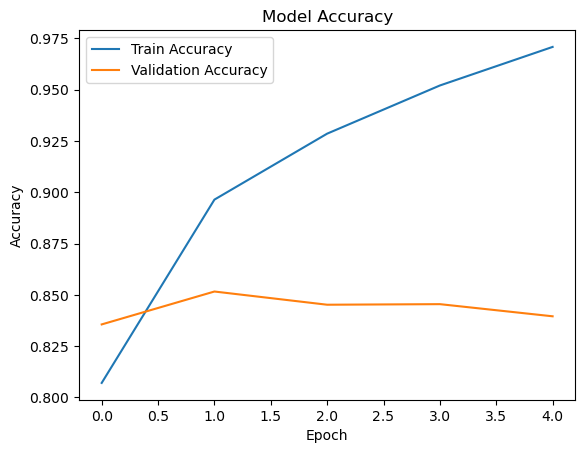

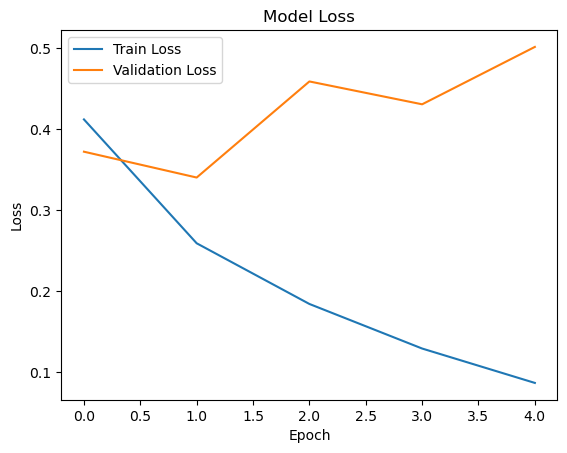

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8396 - loss: 0.5012

Test Accuracy: 0.8395599722862244
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step

Prediction Value: 0.035875935
Sentiment: Negative 😞


In [1]:
# ---------------------------------------------------------
# Sentiment Analysis using LSTM (RNN)
# Dataset: IMDB Reviews
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# --------------------------------
# Step 1: Load Dataset
# --------------------------------
num_words = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=num_words)

print("Dataset Loaded")

# --------------------------------
# Step 2: Data Preprocessing
# --------------------------------
max_len = 100

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# --------------------------------
# Step 3: Define LSTM Model
# --------------------------------
model = Sequential()

model.add(Embedding(num_words, 128, input_length=max_len))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("\nModel Summary:")
model.summary()

# --------------------------------
# Step 4: Train Model
# --------------------------------
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=32,
                    validation_data=(X_test, y_test))

# --------------------------------
# Step 5: Plot Accuracy (Chart 1)
# --------------------------------
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# --------------------------------
# Step 6: Plot Loss (Chart 2)
# --------------------------------
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --------------------------------
# Step 7: Evaluate Model
# --------------------------------
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

# --------------------------------
# Step 8: Prediction (CORRECT WAY)
# --------------------------------
# Using existing test sample (BEST for exam)
sample = X_test[0]

prediction = model.predict(sample.reshape(1, -1))

print("\nPrediction Value:", prediction[0][0])

if prediction > 0.5:
    print("Sentiment: Positive 😊")
else:
    print("Sentiment: Negative 😞")